# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.58MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


In [2]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


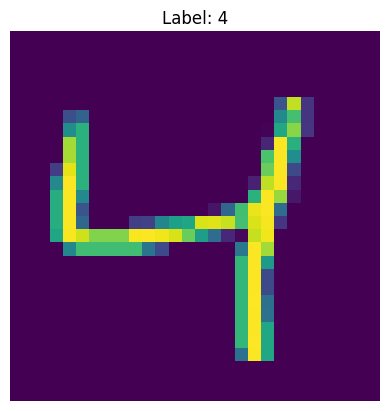

In [3]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [4]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [8]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [9]:
# ANN 객체 생성
input_dim = 784  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [11]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 784)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 784)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.1526583880186081  Accuracy: 96.49737548828125 %
Iteration: 1000  Loss: 0.14756116271018982  Accuracy: 97.31465148925781 %
Iteration: 1500  Loss: 0.20750902593135834  Accuracy: 97.2757339477539 %
Iteration: 2000  Loss: 0.017964715138077736  Accuracy: 97.56761932373047 %
Iteration: 2500  Loss: 0.09378750622272491  Accuracy: 97.89842224121094 %
Iteration: 3000  Loss: 0.06523844599723816  Accuracy: 97.95680236816406 %
Iteration: 3500  Loss: 0.018590198829770088  Accuracy: 98.1903076171875 %
Iteration: 4000  Loss: 0.1859734207391739  Accuracy: 98.36544036865234 %
Iteration: 4500  Loss: 0.013300152495503426  Accuracy: 98.46273803710938 %


#### **ANN 학습 결과**

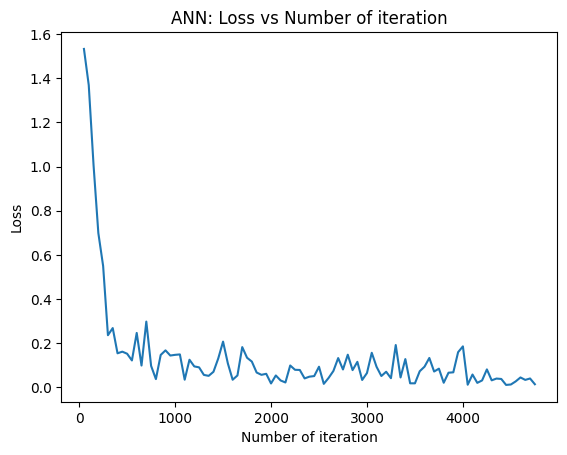

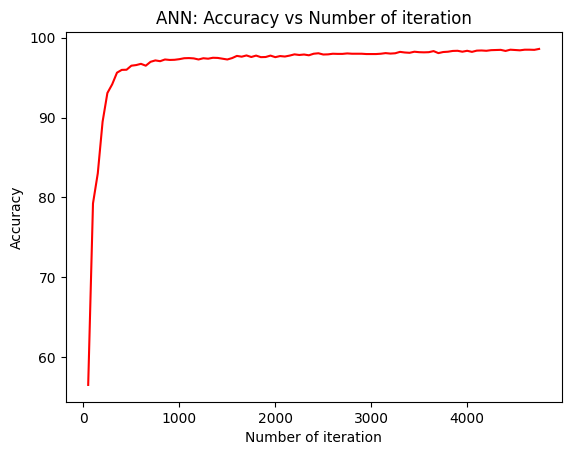

In [12]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**

Loss(손실) 그래프
- 초기의 급격한 하락 이후, 0.0 근처의 매우 작은 값에서 안정화되는 모습을 보임


Accuracy(정확도) 그래프
- 초기의 빠른 상승 이후, 100%의 근접한 확률에서 유지되는 모습을 보임

➡️ 두 그래프를 종합해보면, 현재 모델은 이상적으로 학습이 잘 되고 있다고 해석할 수 있음

손실은 빠르게 감소하고 정확도는 빠르게 상승하여 모두 최적의 상태에 도달했기 때문


#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [13]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# 하이퍼파라미터 설정
input_dim = 784
output_dim = 5
learning_rate = 0.02
hidden_dims = [50, 100, 150, 200]
results_hd = {hd: {'loss': [], 'accuracy': []} for hd in hidden_dims}
epochs = 5

# hidden_dims=[50-200 사이 값들] 로 학습
for hd in hidden_dims:
    print(f"--- hidden_dim = {hd}로 학습 시작 ---")
    model = ANNModel(input_dim, hd, output_dim)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    count = 0
    for epoch in range(epochs):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, input_dim)
            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

            count += 1
            if count % 50 == 0:
                correct = 0
                total = 0
                with torch.no_grad():
                    for test_images, test_labels in test_loader:
                        test = test_images.view(-1, input_dim)
                        outputs = model(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(test_labels)
                        correct += (predicted == test_labels).sum().item()
                accuracy = 100 * correct / total
                results_hd[hd]['loss'].append(loss.item())
                results_hd[hd]['accuracy'].append(accuracy)
    print(f"--- hidden_dim = {hd} 학습 완료 ---")

--- hidden_dim = 50로 학습 시작 ---
--- hidden_dim = 50 학습 완료 ---
--- hidden_dim = 100로 학습 시작 ---
--- hidden_dim = 100 학습 완료 ---
--- hidden_dim = 150로 학습 시작 ---
--- hidden_dim = 150 학습 완료 ---
--- hidden_dim = 200로 학습 시작 ---
--- hidden_dim = 200 학습 완료 ---


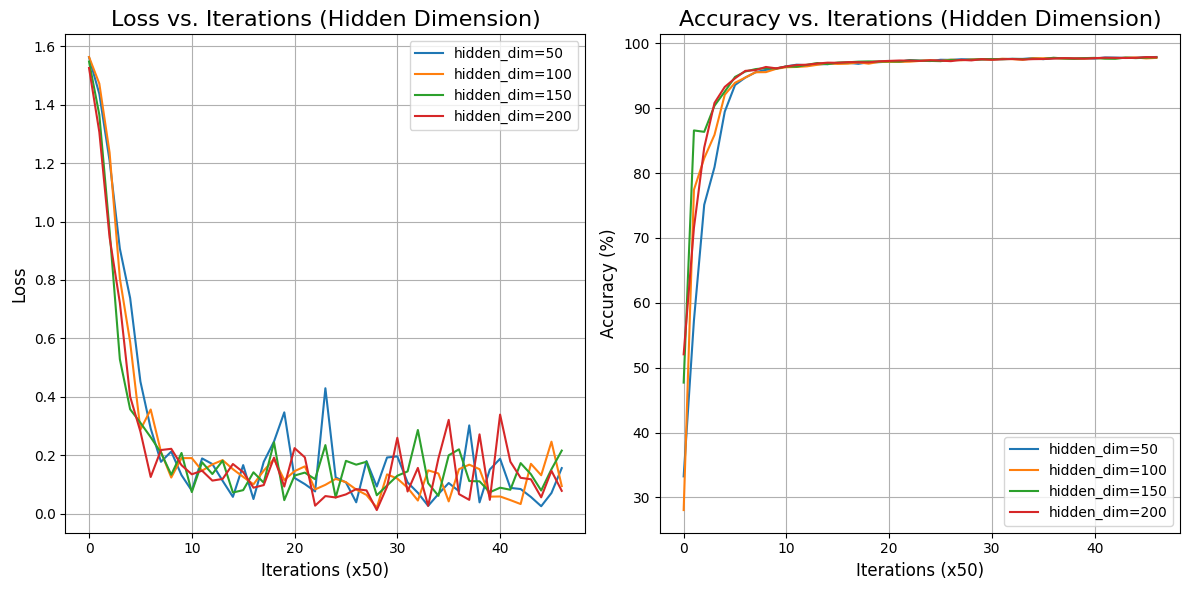

In [14]:
# 실험 1 모델 학습 결과 시각화
plt.figure(figsize=(12, 6))

# Loss 그래프
plt.subplot(1, 2, 1)
for hd in hidden_dims:
    plt.plot(results_hd[hd]['loss'], label=f'hidden_dim={hd}')
plt.title('Loss vs. Iterations (Hidden Dimension)', fontsize=16)
plt.xlabel('Iterations (x50)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

# Accuracy 그래프
plt.subplot(1, 2, 2)
for hd in hidden_dims:
    plt.plot(results_hd[hd]['accuracy'], label=f'hidden_dim={hd}')
plt.title('Accuracy vs. Iterations (Hidden Dimension)', fontsize=16)
plt.xlabel('Iterations (x50)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- 작은 hidden dimension(50): 모델의 용량이 작아 손실이 불안정하게 변동될 수 있지만, 반복을 거쳐 높은 정확도에 도달할 수 있음.
- 적절한 hidden dimension(100, 150, 200): 더 안정적이고 빠르게 높은 정확도에 도달함.
- 100 또는 150 이상의 크기는 정확도를 크게 향상 시키지 않기 때문에, 불필요한 계산량을 줄이기 위해 100 또는 150으로 설정하는 것이 적합해 보임.

In [16]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
learning_rates = [0.1, 0.05, 0.01, 0.005]
results_lr = {lr: {'loss': [], 'accuracy': []} for lr in learning_rates}
epochs = 5

for lr in learning_rates:
    print(f"--- learning_rate = {lr}로 학습 시작 ---")
    model = ANNModel(input_dim, hidden_dim, output_dim)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    count = 0
    for epoch in range(epochs):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, input_dim)
            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

            count += 1
            if count % 50 == 0:
                correct = 0
                total = 0
                with torch.no_grad():
                    for test_images, test_labels in test_loader:
                        test = test_images.view(-1, input_dim)
                        outputs = model(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(test_labels)
                        correct += (predicted == test_labels).sum().item()
                accuracy = 100 * correct / total
                results_lr[lr]['loss'].append(loss.item())
                results_lr[lr]['accuracy'].append(accuracy)
    print(f"--- learning_rate = {lr} 학습 완료 ---")

--- learning_rate = 0.1로 학습 시작 ---
--- learning_rate = 0.1 학습 완료 ---
--- learning_rate = 0.05로 학습 시작 ---
--- learning_rate = 0.05 학습 완료 ---
--- learning_rate = 0.01로 학습 시작 ---
--- learning_rate = 0.01 학습 완료 ---
--- learning_rate = 0.005로 학습 시작 ---
--- learning_rate = 0.005 학습 완료 ---


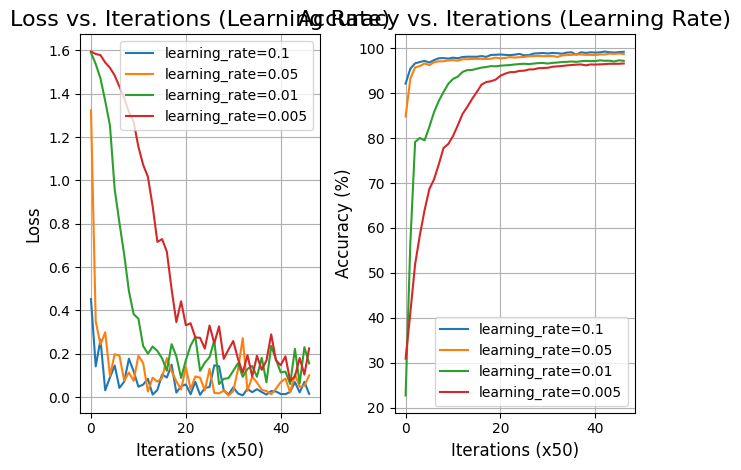

In [17]:
# 실험 2 모델 학습 결과 시각화
# Loss 그래프
plt.subplot(1, 2, 1)
for lr in learning_rates:
    plt.plot(results_lr[lr]['loss'], label=f'learning_rate={lr}')
plt.title('Loss vs. Iterations (Learning Rate)', fontsize=16)
plt.xlabel('Iterations (x50)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

# Accuracy 그래프
plt.subplot(1, 2, 2)
for lr in learning_rates:
    plt.plot(results_lr[lr]['accuracy'], label=f'learning_rate={lr}')
plt.title('Accuracy vs. Iterations (Learning Rate)', fontsize=16)
plt.xlabel('Iterations (x50)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- learning rate가 너무 높으면 학습이 불안정해지고 최적점에 도달하지 못할 수 있음
- learning rate가 너무 낮으면 학습은 안정적이지만, 시간이 너무 오래 걸려 비효율적임
- 안정성과 학습 속도의 균형을 맞춰야 함. 이 경우 0.01이 최적의 학습률로 판단됨

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU() # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32*4*4, 10)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [19]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [20]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.5225466186888438
Epoch 2, Loss: 0.12579215195084414
Epoch 3, Loss: 0.10190180186201704
Epoch 4, Loss: 0.0879308317169656
Epoch 5, Loss: 0.07768268654966777
Epoch 6, Loss: 0.06841061583774588
Epoch 7, Loss: 0.06104479516790266
Epoch 8, Loss: 0.05514431400088465
Epoch 9, Loss: 0.05050424139072734
Epoch 10, Loss: 0.04654454455238481
Epoch 11, Loss: 0.0432484032084829
Epoch 12, Loss: 0.0405859036219456
Epoch 13, Loss: 0.03833804168084166
Epoch 14, Loss: 0.036180773372266106
Epoch 15, Loss: 0.03421482947949828
Epoch 16, Loss: 0.03233060314653476
Epoch 17, Loss: 0.03085862882792588
Epoch 18, Loss: 0.02957990165704585
Epoch 19, Loss: 0.028250075578854235
Epoch 20, Loss: 0.026779014743857976


#### **CNN 학습 결과**

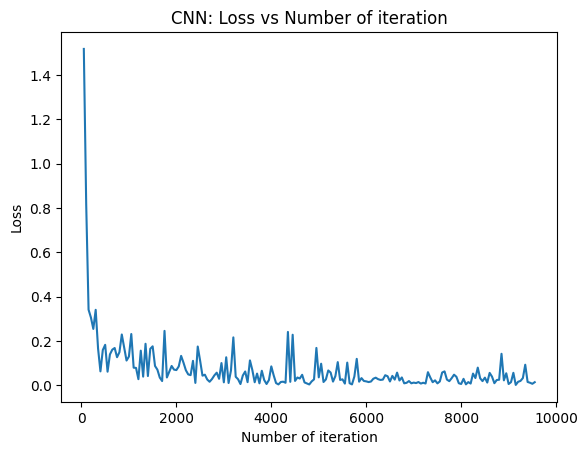

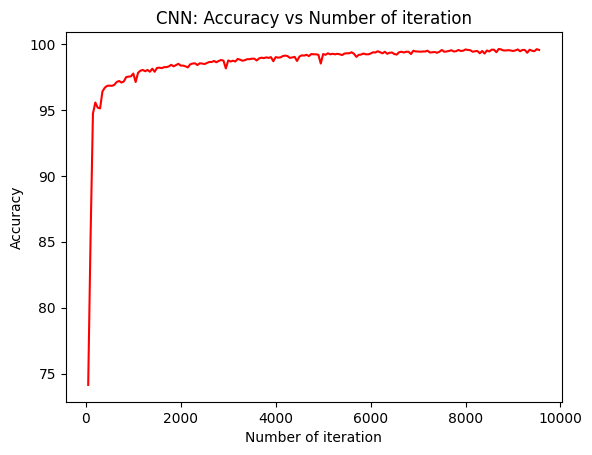

In [21]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
### ✅ 기본 설명
1. ANN (인공 신경망)
- 입력, 은닉, 출력층으로 구성된 가장 기본적인 신경망 모델
- 이미지를 1차원 데이터로 변환하여 처리하기 때문에 픽셀 간의 공간적 관계를 학습하는 데 한계가 있음
- 이로 인해 이미지 분류와 같은 작업에서는 효율성이 떨어지는 경향이 있음

2. CNN (합성곱 신경망)
- 합성곱 계층과 풀링 계층을 사용하여 이미지의 특징을 효과적으로 추출하는 데 특화된 신경망
- 이미지를 그대로 입력으로 받아 필터를 통해 중요한 공간적 특징을 자동으로 학습하므로, 이미지 분류 작업에 매우 강력한 성능을 발휘


### ✅ ANN과 CNN의 MNIST 학습 결과 비교

1. 학습 속도 및 안정성
- ANN: 일반적으로 ANN은 MNIST와 같은 복잡한 이미지 데이터를 학습하는 데 어려움을 겪음. 학습 과정에서 손실(Loss)이 크게 요동치고, 정확도(Accuracy)가 낮은 수준에 머무르는 경우가 많음.

- CNN: 초반에 손실이 매우 가파르게 감소하고, 그 후 낮은 값에서 안정적으로 유지됨. 즉, 모델이 이미지를 효율적으로 학습함.

2. 성능
- ANN: ANN 모델은 MNIST 데이터셋에서 흔히 무작위 추측과 크게 다르지 않은 낮은 정확도를 보임. 이는 픽셀 데이터를 1차원 배열로 변환하는 과정에서 중요한 공간적 정보가 손실되기 때문.

- CNN: 압도적으로 높은 정확도를 달성. 정확도 그래프가 초반에 95% 이상으로 빠르게 상승하고, 최종적으로 99%에 가까운 수준에 도달하여 안정화됨.

### ✅ 결론
MNIST 데이터셋과 같은 이미지 분류 작업에서는 CNN이 ANN보다 훨씬 우월한 성능을 보임. CNN은 이미지의 공간적 구조를 보존하고 특징을 효과적으로 추출하는 구조 덕분에 더 빠르고 안정적으로 학습하며, 결과적으로 훨씬 높은 정확도를 달성함. 따라서 이미지 데이터에는 CNN을 사용하는 것이 훨씬 더 효과적!